# Imports

In [ ]:
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import optax

# Data

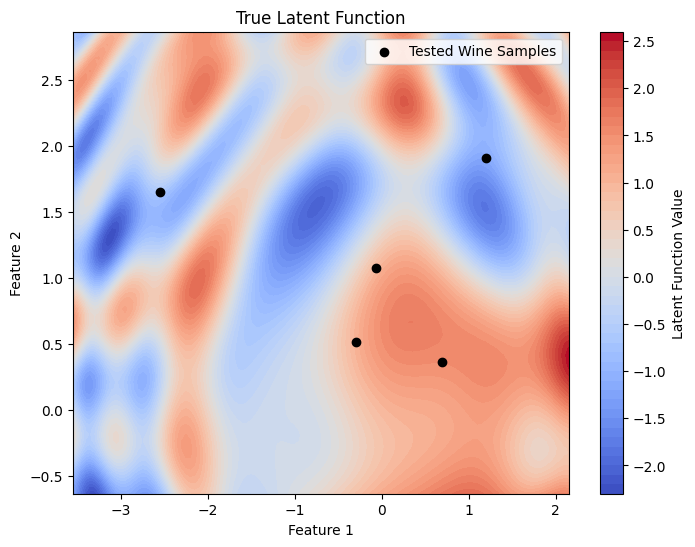

In [2]:
def latent_function(x):
    x0 = x[..., 0]
    x1 = x[..., 1]

    background = (
        0.8 * jnp.sin(2.0 * x0 * x1)
        + 0.6 * jnp.cos(3.0 * x0)
        + 0.6 * jnp.sin(3.0 * x1)
        + 0.5 * jnp.sin(1.5 * (x0**2 + x1**2))
    )

    dominant_peak = 4 * jnp.exp(-1.0 * ((x0 - 1.2) ** 2 + (x1 + 1.0) ** 2))

    return background + dominant_peak


def generate_initial_preference_data(
    num_points=5, num_pairs=25, noise_std=0.5, seed=42
):
    rng = jax.random.PRNGKey(seed)
    X = jax.random.uniform(rng, shape=(num_points, 2), minval=-3, maxval=3)

    latent_values = latent_function(X)
    # Sample pairs of points and generate preferences based on the latent function values with some noise
    rng, rng_subkey = jax.random.split(rng)
    indices_i = jax.random.randint(
        rng_subkey, shape=(num_pairs,), minval=0, maxval=num_points
    )
    rng, rng_subkey = jax.random.split(rng)
    indices_j = jax.random.randint(
        rng_subkey, shape=(num_pairs,), minval=0, maxval=num_points
    )
    X_i = X[indices_i]
    X_j = X[indices_j]
    latent_diff = latent_values[indices_i] - latent_values[indices_j]
    rng, rng_subkey = jax.random.split(rng)
    noise = noise_std * jax.random.normal(rng_subkey, shape=latent_diff.shape)
    y_ij = (latent_diff + noise > 0).astype(
        jnp.float32
    )  # 1 if i preferred to j, 0 otherwise
    return X_i, X_j, y_ij, X, latent_values


# Vectorized Data Generation
def sample_preferences(
    rng_key, candidate_1, candidate_2, preference_samples_per_location=25
):
    # Calculate the probability once
    latent_diff = latent_function(candidate_1) - latent_function(candidate_2)
    sigmoid_prob = jax.nn.sigmoid(latent_diff)

    # Draw all preference samples at once using the shape argument
    rng_key, rng_subkey = jax.random.split(rng_key)
    preferences = jax.random.bernoulli(
        rng_subkey, p=sigmoid_prob, shape=(preference_samples_per_location,)
    ).astype(jnp.float32)

    # Tile the candidates to match the number of samples
    new_X_i = jnp.tile(
        candidate_1, (preference_samples_per_location, 1)
    )  # Shape: (preference_samples_per_location, 2)
    new_X_j = jnp.tile(
        candidate_2, (preference_samples_per_location, 1)
    )  # Shape: (preference_samples_per_location, 2)
    new_y_ij = preferences  # Shape: (preference_samples_per_location,)

    return new_X_i, new_X_j, new_y_ij


def make_grid(var1, var2, h=0.05):
    x1_min = jnp.minimum(var1[:, 0].min(), var2[:, 0].min()) - 1
    x1_max = jnp.maximum(var1[:, 0].max(), var2[:, 0].max()) + 1
    y_min = jnp.minimum(var1[:, 1].min(), var2[:, 1].min()) - 1
    y_max = jnp.maximum(var1[:, 1].max(), var2[:, 1].max()) + 1
    xx1, xx2 = jnp.meshgrid(jnp.arange(x1_min, x1_max, h), jnp.arange(y_min, y_max, h))
    grid_inputs = jnp.c_[xx1.ravel(), xx2.ravel()]
    return xx1, xx2, grid_inputs


# Data generation
X_i, X_j, y_ij, X, latent_values = generate_initial_preference_data()
xx1, xx2, grid_inputs = make_grid(X_i, X_j)
grid_latent = latent_function(grid_inputs)

# True latent function
plt.figure(figsize=(8, 6))
plt.contourf(xx1, xx2, grid_latent.reshape(xx1.shape), levels=50, cmap="coolwarm")
plt.colorbar(label="Latent Function Value")


# Sampled data
X_samples = jnp.concatenate((X_i, X_j), axis=0)
X_unique = jnp.unique(X_samples, axis=0)
plt.scatter(
    X_unique[:, 0],
    X_unique[:, 1],
    c="black",
    label="Tested Wine Samples",
)

# Plot
plt.title("True Latent Function")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Given Functions from Part A

In [3]:
# This code uses broadcasting to compute the RBF kernel matrix, for multivariate inputs, and also has a diagonal-only option.
def rbf_kernel(x1, x2, lengthscale, variance, diag=False):
    # If you provide a flat vector for 1d inputs, reshape to general 2D format (N, D).
    if x1.ndim == 1:
        x1 = x1.reshape(-1, 1)
        x2 = x2.reshape(-1, 1)
    if diag:
        # Still use the distances (in case x1 and x2 are different but equal length datasets and we want the diagonal) but only return the diagonal of the kernel matrix.
        dist_sq_diag = jnp.sum((x1 - x2) ** 2, axis=-1)
        return variance * jnp.exp(-0.5 * dist_sq_diag / (lengthscale**2))
    else:
        # Note that the extra dimension that we sum over is redundant because we only have 1D inputs.
        # But we keep the code general for potential multi-dimensional inputs.
        dist_sq = jnp.sum((x1[:, None, :] - x2[None, :, :]) ** 2, axis=-1)
        return variance * jnp.exp(-0.5 * dist_sq / (lengthscale**2))


# Cholesky with jitter
def stable_cholesky(K, jitter=1e-5):
    return jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))

# Functions

In [4]:
def sparse_gp_predict(params, X_test, full_cov=False):
    mu_z = params["mean_z"]
    diagonal_L_z = params["diagonal_L_z"]
    strictly_lower_L_z = params["strictly_lower_L_z"]
    inducing_points = params["inducing_points"]
    kernel_ls = jnp.exp(params["kernel_log_lengthscale"])
    kernel_var = jnp.exp(params["kernel_log_variance"])

    # Construct Cholesky factor
    L = jnp.tril(strictly_lower_L_z, k=-1)
    diag = jax.nn.softplus(diagonal_L_z) + 1e-6
    L += jnp.diag(diag)

    # Calculate full covariance of q(z)
    sigma_z = L @ L.T

    # Kernels
    K_uu = rbf_kernel(inducing_points, inducing_points, kernel_ls, kernel_var)
    K_uf = rbf_kernel(inducing_points, X_test, kernel_ls, kernel_var)
    K_ff = rbf_kernel(X_test, X_test, kernel_ls, kernel_var, diag=not (full_cov))

    # Cholesky of K_uu -> K_uu = L_uu . L_uu^T
    L_uu = stable_cholesky(K_uu)

    # Predictive mean
    v = jsp.linalg.solve_triangular(L_uu, K_uf, lower=True)
    mu_t = v.T @ mu_z

    # Covariance
    if full_cov:
        cov_t = K_ff - v.T @ v
        cov_t += v.T @ sigma_z @ v
    else:
        cov_t = K_ff - jnp.sum(v**2, axis=0)
        cov_t += jnp.sum(v * (sigma_z @ v), axis=0)

    return mu_t, cov_t


def to_z_space(x1, x2, lengthscale, variance, mu_u):
    K_uu = rbf_kernel(x1, x2, lengthscale, variance)
    L_uu = stable_cholesky(K_uu)
    mu_z = jsp.linalg.solve_triangular(L_uu, mu_u, lower=True)
    return mu_z


def kl_divergence(params):
    mean_z = params["mean_z"]
    diagonal_L_z = params["diagonal_L_z"]
    strictly_lower_L_z = params["strictly_lower_L_z"]

    # Construct Cholesky factor
    L = jnp.tril(strictly_lower_L_z, k=-1)
    diag = jax.nn.softplus(diagonal_L_z) + 1e-6
    L += jnp.diag(diag)

    # Covariance of q(z)
    sigma_z = L @ L.T

    # tr(sigma_z)
    traceTerm = jnp.trace(sigma_z)

    # mu_z^T . mu_z
    quadTerm = jnp.dot(mean_z, mean_z)

    # log|sigma_z| = log|L . L^T| = 2 * log(L)
    logdet = 2 * jnp.sum(jnp.log(jnp.diag(L)))

    M = mean_z.shape[0]

    return 0.5 * (traceTerm + quadTerm - M - logdet)


def mc_log_likelihood(params, X_i_b, X_j_b, y_b, N, key, num_mc_samples=100):
    B = X_i_b.shape[0]
    X_concat_b = jnp.concatenate((X_i_b, X_j_b), axis=0)

    mu_concat_b, cov_concat_b = sparse_gp_predict(params, X_concat_b, full_cov=True)

    mu_i_b = mu_concat_b[:B]
    mu_j_b = mu_concat_b[B:]
    var_i_b = jnp.diag(cov_concat_b[:B, :B])
    var_j_b = jnp.diag(cov_concat_b[B:, B:])
    cov_ij_b = jnp.diag(cov_concat_b[:B, B:])

    # Difference of gaussians
    mu_b = mu_i_b - mu_j_b
    cov_b = var_i_b + var_j_b - 2 * cov_ij_b

    mu_b = mu_b.reshape(-1)
    cov_b = cov_b.reshape(-1)
    y_b = y_b.reshape(-1)

    # Reparameterisation
    std_b = jnp.sqrt(jnp.maximum(cov_b, 1e-6))
    z = jax.random.normal(key, shape=(num_mc_samples, B))
    difference_samples = mu_b[None, :] + std_b[None, :] * z

    # Log Bradley-Terry likelihood
    # Difference = f_i - f_j
    # y_n . log(sig(difference)) + (1-y_n) . log(1-sig(difference))
    log_likelihood_term_1 = y_b[None, :] * jax.nn.log_sigmoid(difference_samples)
    log_likelihood_term_2 = (1 - y_b[None, :]) * jnp.log(
        1 - jax.nn.sigmoid(difference_samples)
    )
    log_likelihood = log_likelihood_term_1 + log_likelihood_term_2

    # Minibatch
    return (N / B) * jnp.mean(jnp.sum(log_likelihood, axis=1), axis=0)


def mc_elbo(params, X_i_b, X_j_b, y_b, N, key):
    expected_log_lh = mc_log_likelihood(params, X_i_b, X_j_b, y_b, N, key)
    kl_div = kl_divergence(params)

    return expected_log_lh - kl_div


def mc_step(params, opt, opt_state, X_i_b, X_j_b, y_b, N, key):
    loss_fn = lambda p: -mc_elbo(p, X_i_b, X_j_b, y_b, N, key)

    value, grads = jax.value_and_grad(loss_fn)(params)

    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    return params, opt_state, value


def get_mc_batches(key, X_i, X_j, y, batch_size):
    n = X_i.shape[0]
    perm = jax.random.permutation(key, n)

    X_i_shuffled = X_i[perm]
    X_j_shuffled = X_j[perm]
    y_shuffled = y[perm]

    for i in range(0, n, batch_size):
        yield X_i_shuffled[i : i + batch_size], X_j_shuffled[
            i : i + batch_size
        ], y_shuffled[i : i + batch_size]


# Task B Specific
def sample_from_gp(key, mu, cov, num_samples):
    L = stable_cholesky(cov)
    key, subkey = jax.random.split(key)
    z = jax.random.normal(subkey, shape=(num_samples, mu.shape[0]))
    f_samples = mu[None, :] + z @ L.T

    return f_samples, key


# Task B Specific
def thompson_get_new_inputs_from_gp(key, mu, cov, grid_inputs, num_samples):
    f_samples, key = sample_from_gp(key, mu, cov, num_samples)

    # Grid search
    next_idxs = jnp.argmax(f_samples, axis=1)
    new_X = grid_inputs[next_idxs]

    return new_X, key


# Task B Specific
def get_new_training_dataset(key, params, X_i_train, X_j_train, y_train, grid_inputs):
    # Thompson sampling from posterior
    mu_f, cov_f = sparse_gp_predict(params, grid_inputs, full_cov=True)
    new_X, key = thompson_get_new_inputs_from_gp(
        key, mu_f, cov_f, grid_inputs, num_samples=2
    )
    new_X_i = new_X[0]
    new_X_j = new_X[1]

    key, subkey = jax.random.split(key)

    new_X_i, new_X_j, new_y_ij = sample_preferences(subkey, new_X_i, new_X_j)

    # Update model with new data
    X_i_train = jnp.concatenate((X_i_train, new_X_i), axis=0)
    X_j_train = jnp.concatenate((X_j_train, new_X_j), axis=0)
    y_train = jnp.concatenate((y_train, new_y_ij), axis=0)
    N = X_i_train.shape[0]
    return X_i_train, X_j_train, y_train, N, key


def train_loop(
    num_epochs,
    batch_size,
    key,
    params,
    X_i_train,
    X_j_train,
    y_train,
    grid_inputs,
    opt,
    opt_state,
    debug=False,
    thompson_sample=False,
):
    elbo_history = []
    N = X_i_train.shape[0]

    for epoch in range(num_epochs):
        epoch_elbo_history = []

        if thompson_sample:
            X_i_train, X_j_train, y_train, N, key = get_new_training_dataset(
                key, params, X_i_train, X_j_train, y_train, grid_inputs
            )

        key, subkey = jax.random.split(key)

        for X_i_batch, X_j_batch, y_batch in get_mc_batches(
            subkey, X_i_train, X_j_train, y_train, batch_size
        ):
            key, subkey = jax.random.split(key)
            params, opt_state, elbo_val = mc_step(
                params, opt, opt_state, X_i_batch, X_j_batch, y_batch, N, subkey
            )

            epoch_elbo_history.append(-elbo_val)

        avg_epoch_elbo = jnp.mean(jnp.array(epoch_elbo_history))
        elbo_history.append(avg_epoch_elbo)

        if debug and epoch % 5 == 0:
            ell = mc_log_likelihood(params, X_i_batch, X_j_batch, y_batch, N, key)
            kl = kl_divergence(params)
            print(f"Epoch {epoch}, ELL: {ell:.2f}, KL: {kl:.2f}, ELBO: {ell-kl:.2f}")

    return X_i_train, X_j_train, y_train, params, opt_state, elbo_history, key

# Configs

In [5]:
full_cov = False

# Initial parameters
initial_diagonal_values = -0.5
initial_kernel_log_lengthscale_value = 1.0
initial_kernel_log_variance_value = 1.0


# Training
adam_learning_rate = 1e-3
num_epochs = 200
batch_size = 128

# Procedure

In [ ]:
### Initialisation ###

# Intitialise initial points as inducing points
X_concat = jnp.concatenate((X_i, X_j), axis=0)
X_concat = jnp.asarray(X_concat)
inducing_points = jnp.unique(X_concat, axis=0)
M = inducing_points.shape[0]

# Initial parameters
initial_mean = jnp.zeros(M)
initial_lower_diag = jnp.zeros((M, M))

# Initialise parameters
mu_u = initial_mean
diagonal_L_z = jnp.full((M,), initial_diagonal_values)
strictly_lower_L_z = initial_lower_diag
kernel_log_lengthscale = jnp.log(jnp.array(initial_kernel_log_lengthscale_value))
kernel_log_variance = jnp.log(jnp.array(initial_kernel_log_variance_value))

# Transform initial mean to z-space
mu_z = to_z_space(
    inducing_points,
    inducing_points,
    jnp.exp(kernel_log_lengthscale),
    jnp.exp(kernel_log_variance),
    mu_u,
)

params = {
    "mean_z": mu_z,
    "diagonal_L_z": diagonal_L_z,
    "strictly_lower_L_z": strictly_lower_L_z,
    "inducing_points": inducing_points,
    "kernel_log_lengthscale": kernel_log_lengthscale,
    "kernel_log_variance": kernel_log_variance,
}

# Initialise Optimiser
opt = optax.adam(learning_rate=adam_learning_rate)
opt_state = opt.init(params)

### Training Loop ###

key = jax.random.PRNGKey(0)

# Initial training
X_i_train, X_j_train, y_train, params, opt_state, elbo_history, key = train_loop(
    num_epochs,
    batch_size,
    key,
    params,
    X_i,
    X_j,
    y_ij,
    grid_inputs,
    opt,
    opt_state,
    debug=False,
)

X_i_train, X_j_train, y_train, params, opt_state, elbo_history, key = train_loop(
    num_epochs,
    batch_size,
    key,
    params,
    X_i_train,
    X_j_train,
    y_train,
    grid_inputs,
    opt,
    opt_state,
    debug=False,
    thompson_sample=True,
)

# Predict
mu_f, var_f = sparse_gp_predict(params, grid_inputs, full_cov=False)

# Plotting

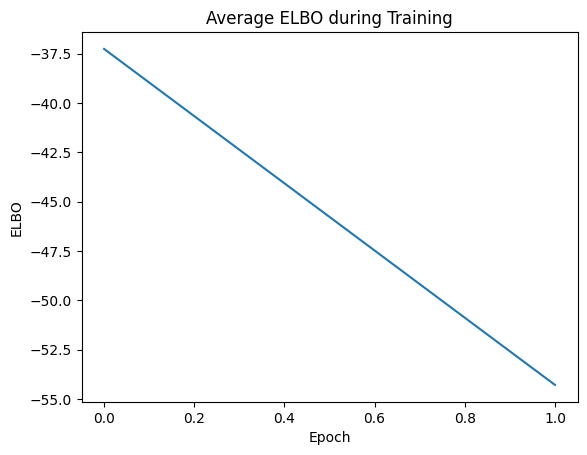

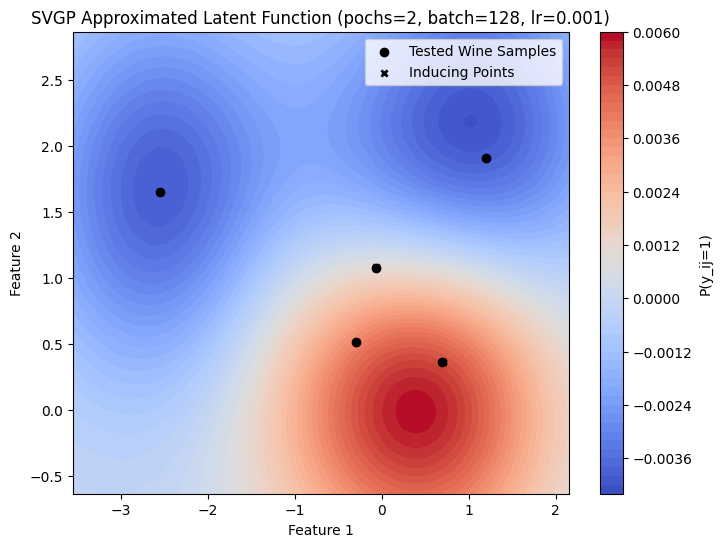

In [ ]:
### Plotting ###

plt.plot(elbo_history)
plt.xlabel("Epoch")
plt.ylabel("ELBO")
plt.title("Average ELBO during Training")
plt.show()

# Probability predictions
plt.figure(figsize=(8, 6))
plt.contourf(xx1, xx2, mu_f.reshape(xx1.shape), levels=50, cmap="coolwarm")
plt.colorbar(label="P(y_ij=1)")

X_set = jnp.unique(X_concat, axis=0)

# Sampled data
plt.scatter(
    X_set[:, 0],
    X_set[:, 1],
    c="black",
    label="Tested Wine Samples",
    linewidths=1
)

# Inducing points
inducing_points = params["inducing_points"]
plt.scatter(
    inducing_points[:, 0],
    inducing_points[:, 1],
    color="black",
    s=20,
    marker="x",
    linewidths=2,
    label="Inducing Points",
)

# Plot
plt.title(f"SVGP Approximated Latent Function (epochs={num_epochs}, batch={batch_size}, lr={adam_learning_rate})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()